In [0]:
from pyspark.sql import functions as F

# Carregamento das tabelas analíticas da camada Gold

df_municipio = spark.table("mvp_1.gold.indicadores_municipio")
df_uf = spark.table("mvp_1.gold.indicadores_uf")
df_regiao = spark.table("mvp_1.gold.indicadores_regiao")

print("Tabelas Gold carregadas com sucesso.")

Tabelas Gold carregadas com sucesso.


Análise dos dados

Nesta etapa são analisados os dados consolidados na camada Gold com o objetivo de avaliar a evolução e a distribuição geográfica da cobertura vacinal contra o sarampo no Brasil.

As análises consideram os indicadores TVD1/SCR D1, TVD2/SCR D2 e SCRVZ, utilizando município, Unidade da Federação e região.

Os dados de PIB municipal são utilizados em análises complementares para investigar possíveis relações entre características econômicas dos municípios e os indicadores de cobertura vacinal.

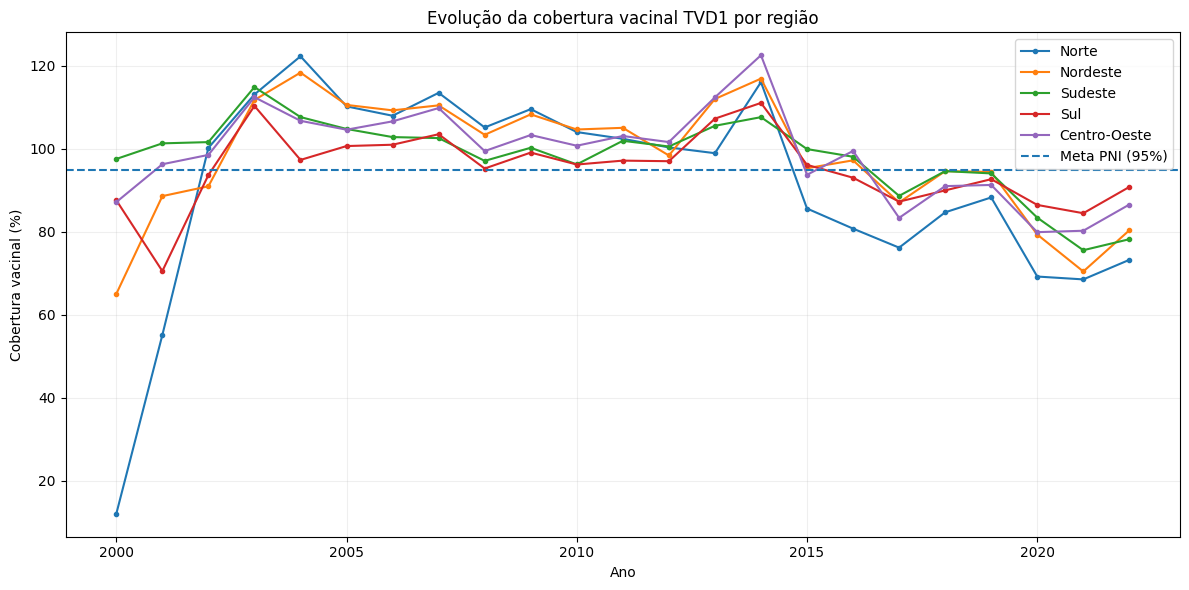

In [0]:
#Utilizei a função matplotlib.pyplot para conseguir colocar uma linha guia de 95% no gráfico

import matplotlib.pyplot as plt

# Dados regionais da TVD1 a partir de 2000
pdf_tvd1_regiao = (
    df_regiao
    .filter(F.col("ano") >= 2000)
    .select("ano", "regiao", "cobertura_tvd1")
    .orderBy("ano")
    .toPandas()
)

plt.figure(figsize=(12, 6))

# Uma linha para cada região
for regiao in pdf_tvd1_regiao["regiao"].unique():
    dados = pdf_tvd1_regiao[pdf_tvd1_regiao["regiao"] == regiao]

    plt.plot(
        dados["ano"],
        dados["cobertura_tvd1"],
        marker="o",
        markersize=3,
        label=regiao
    )

# Meta de cobertura
plt.axhline(
    y=95,
    linestyle="--",
    linewidth=1.5,
    label="Meta PNI (95%)"
)

plt.title("Evolução da cobertura vacinal TVD1 por região")
plt.xlabel("Ano")
plt.ylabel("Cobertura vacinal (%)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

As regiões ficam próximas de 100% em boa parte dos anos 2000/início de 2010, há um pico em torno de 2013–2014 e depois uma queda mais evidente, especialmente a partir de 2015/2016, com diferenças regionais mais fortes nos anos recentes.

Comparação entre TVD1, TVD2 e SCRV, onde serão analisados separadamente.

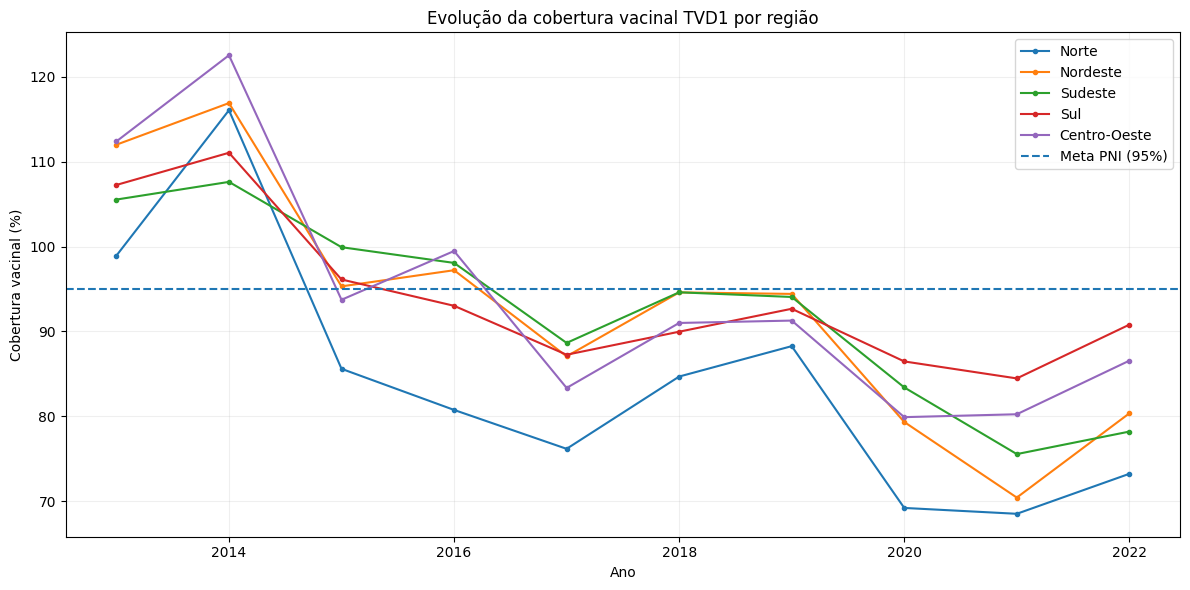

In [0]:
#Utilizei a função matplotlib.pyplot para conseguir colocar uma linha guia de 95% no gráfico

import matplotlib.pyplot as plt

# Dados regionais da TVD1 a partir de 2013
pdf_tvd1_regiao = (
    df_regiao
    .filter(F.col("ano") >= 2013)
    .select("ano", "regiao", "cobertura_tvd1")
    .orderBy("ano")
    .toPandas()
)

plt.figure(figsize=(12, 6))

# Uma linha para cada região
for regiao in pdf_tvd1_regiao["regiao"].unique():
    dados = pdf_tvd1_regiao[pdf_tvd1_regiao["regiao"] == regiao]

    plt.plot(
        dados["ano"],
        dados["cobertura_tvd1"],
        marker="o",
        markersize=3,
        label=regiao
    )

# Meta de cobertura
plt.axhline(
    y=95,
    linestyle="--",
    linewidth=1.5,
    label="Meta PNI (95%)"
)

plt.title("Evolução da cobertura vacinal TVD1 por região")
plt.xlabel("Ano")
plt.ylabel("Cobertura vacinal (%)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

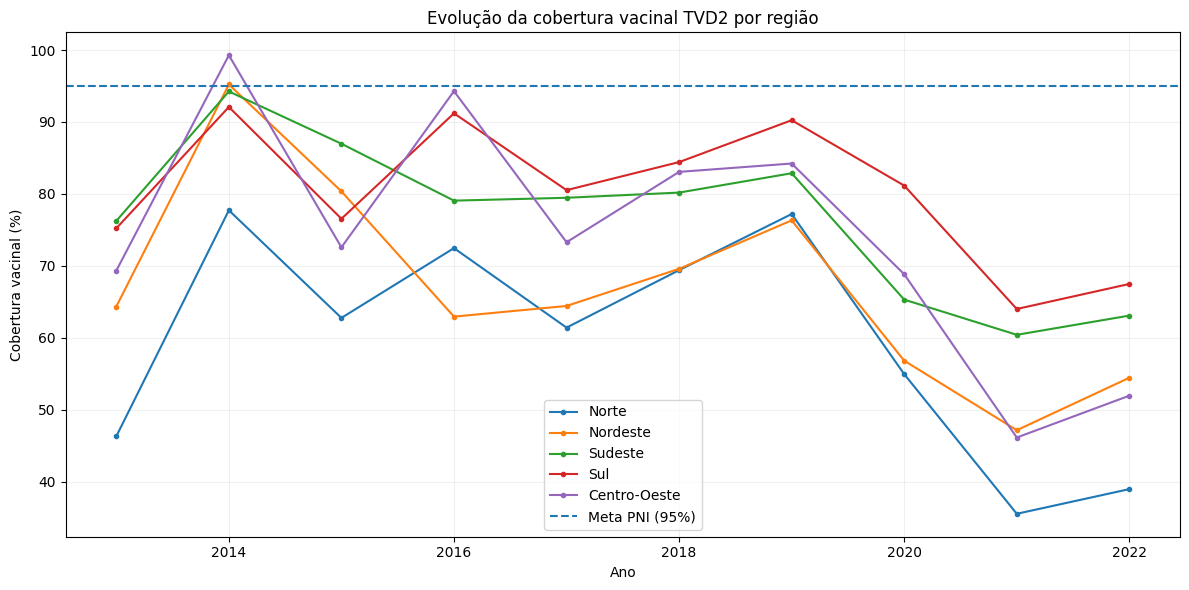

In [0]:
pdf_tvd2_regiao = (
    df_regiao
    .filter(F.col("ano") >= 2013)
    .select("ano", "regiao", "cobertura_tvd2")
    .orderBy("ano")
    .toPandas()
)

plt.figure(figsize=(12, 6))

for regiao in pdf_tvd2_regiao["regiao"].unique():
    dados = pdf_tvd2_regiao[pdf_tvd2_regiao["regiao"] == regiao]

    plt.plot(
        dados["ano"],
        dados["cobertura_tvd2"],
        marker="o",
        markersize=3,
        label=regiao
    )

plt.axhline(
    y=95,
    linestyle="--",
    linewidth=1.5,
    label="Meta PNI (95%)"
)

plt.title("Evolução da cobertura vacinal TVD2 por região")
plt.xlabel("Ano")
plt.ylabel("Cobertura vacinal (%)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

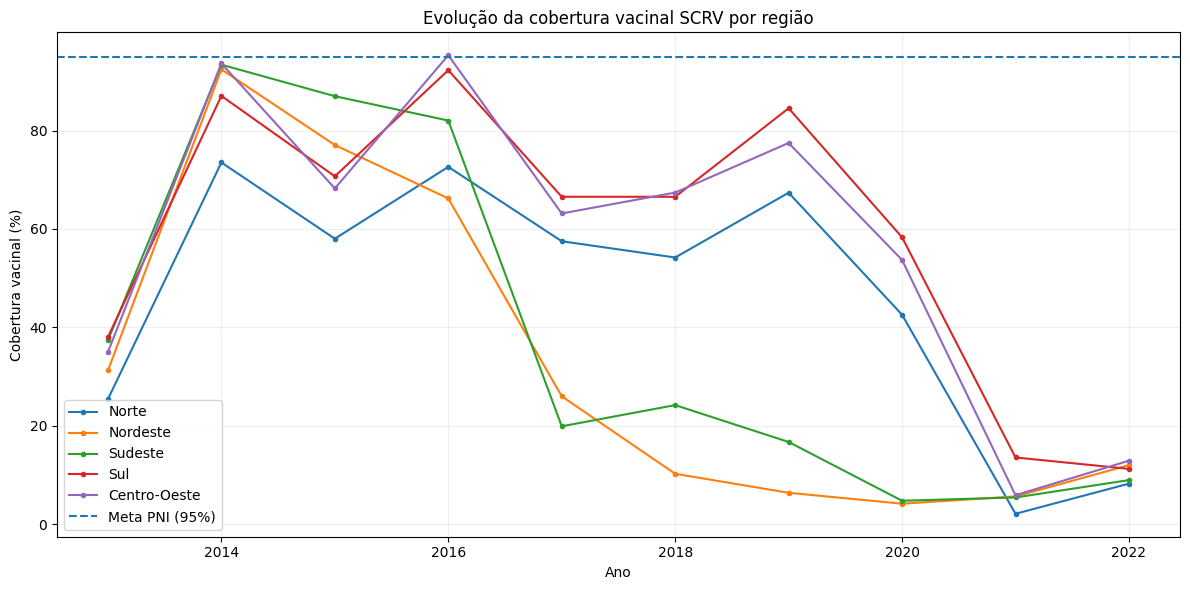

In [0]:
pdf_scrvz_regiao = (
    df_regiao
    .filter(F.col("ano") >= 2013)
    .select("ano", "regiao", "cobertura_scrvz")
    .orderBy("ano")
    .toPandas()
)

plt.figure(figsize=(12, 6))

for regiao in pdf_scrvz_regiao["regiao"].unique():
    dados = pdf_scrvz_regiao[pdf_scrvz_regiao["regiao"] == regiao]

    plt.plot(
        dados["ano"],
        dados["cobertura_scrvz"],
        marker="o",
        markersize=3,
        label=regiao
    )

plt.axhline(
    y=95,
    linestyle="--",
    linewidth=1.5,
    label="Meta PNI (95%)"
)

plt.title("Evolução da cobertura vacinal SCRV por região")
plt.xlabel("Ano")
plt.ylabel("Cobertura vacinal (%)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

PAREI AQUI

In [0]:
Analisando os três gráficos em conjunto podemos notar uma diferença entre as doses aplicadas. A TVD1 apresentou maior cobertura vacinal principalmente no início do período analisado, sendo que a TVD2 registrou abaixo da TVD1 na maior parte dos casos. A SCRVZ apresentou um decaimento preocupante no Nordeste e no Sudeste. Não tem como tirar maiores conclusões utilizando apenas esses dados.
Para complementar a comparação, foi calculada a diferença entre as coberturas da primeira e segunda dose da tríplice viral no período de 2013 a 2022. A diferença foi calculada em pontos percentuais, onde valores positivos indicam que a cobertura da primeira dose foi superior a da segunda dose.


In [0]:
Diferença entre a cobertura da primeira e da segunda dose

Para avaliar a continuidade do esquema vacinal, foi calculada a diferença, em pontos percentuais, entre as coberturas de TVD1 e TVD2 para cada região e ano no período de 2013 a 2022.

O indicador é calculado como TVD1 − TVD2. Valores positivos indicam cobertura da primeira dose superior à da segunda dose. Essa diferença é utilizada como medida descritiva

In [0]:
df_gap_regiao = (
    df_regiao
    .filter(F.col("ano") >= 2013)
    .withColumn(
        "gap_d1_d2",
        F.col("cobertura_tvd1") - F.col("cobertura_tvd2")
    )
    .select(
        "ano",
        "regiao",
        "cobertura_tvd1",
        "cobertura_tvd2",
        "gap_d1_d2"
    )
    .orderBy("ano", "codigo_regiao")
)

display(df_gap_regiao)

ano,regiao,cobertura_tvd1,cobertura_tvd2,gap_d1_d2
2013,Norte,98.93,46.3,52.63000000000001
2013,Nordeste,111.99,64.34,47.64999999999999
2013,Sudeste,105.53,76.24,29.290000000000006
2013,Sul,107.25,75.21,32.040000000000006
2013,Centro-Oeste,112.38,69.33,43.05
2014,Norte,116.05,77.72,38.33
2014,Nordeste,116.89,95.21,21.680000000000007
2014,Sudeste,107.61,94.24,13.370000000000005
2014,Sul,111.04,92.08,18.960000000000008
2014,Centro-Oeste,122.52,99.27,23.25


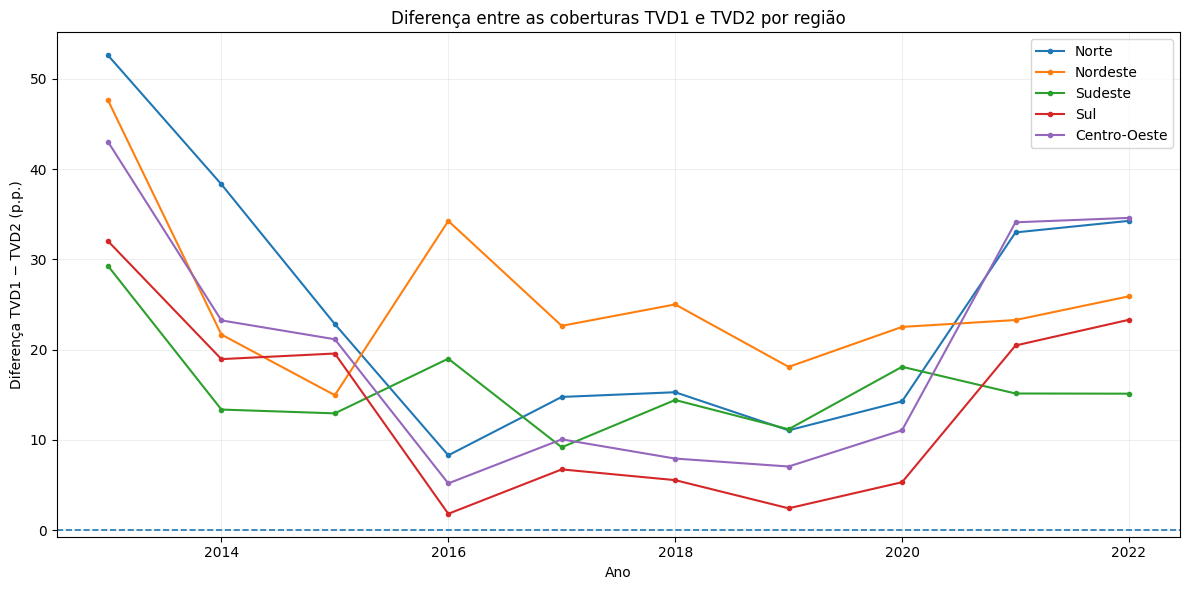

In [0]:
pdf_gap_regiao = (
    df_gap_regiao
    .select(
        "ano",
        "regiao",
        F.round("gap_d1_d2", 2).alias("gap_d1_d2")
    )
    .orderBy("ano")
    .toPandas()
)

plt.figure(figsize=(12, 6))

for regiao in pdf_gap_regiao["regiao"].unique():
    dados = pdf_gap_regiao[pdf_gap_regiao["regiao"] == regiao]

    plt.plot(
        dados["ano"],
        dados["gap_d1_d2"],
        marker="o",
        markersize=3,
        label=regiao
    )

# Linha de referência: ausência de diferença
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2
)

plt.title("Diferença entre as coberturas TVD1 e TVD2 por região")
plt.xlabel("Ano")
plt.ylabel("Diferença TVD1 − TVD2 (p.p.)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

Observa-se que a cobertura da primeira dose permaneceu superior a da segunda durante o período analisado, embora a diferença tenha variado ao longo dos anos, Em 2013 foi observada uma grande diferença das regiões Norte, Nordeste e Centro-Oeste, já em 2020 essa diferença voltou a aumentar nas regiões Norte e Centro-Oeste.

Distribuição da cobertura entre os municípios

Além dos indicadores agregados por região, foi analisada a distribuição das coberturas municipais. Para cada ano, os municípios foram classificados de acordo com a meta de 95% de cobertura.

In [0]:
df_meta_municipio = (
    df_municipio
    .filter(
        (F.col("ano") >= 2000) &
        F.col("cobertura_tvd1").isNotNull()
    )
    .groupBy("ano")
    .agg(
        F.count("*").alias("total_municipios"),
        F.sum(
            F.when(F.col("cobertura_tvd1") >= 95, 1).otherwise(0)
        ).alias("municipios_meta")
    )
    .withColumn(
        "percentual_meta",
        F.round(
            F.col("municipios_meta") /
            F.col("total_municipios") * 100,
            2
        )
    )
    .orderBy("ano")
)

display(df_meta_municipio)

ano,total_municipios,municipios_meta,percentual_meta
2000,5571,1969,35.34
2001,5571,2649,47.55
2002,5571,3078,55.25
2003,5571,4297,77.13
2004,5571,3886,69.75
2005,5571,4069,73.04
2006,5571,4447,79.82
2007,5571,4452,79.91
2008,5571,3597,64.57
2009,5571,4208,75.53


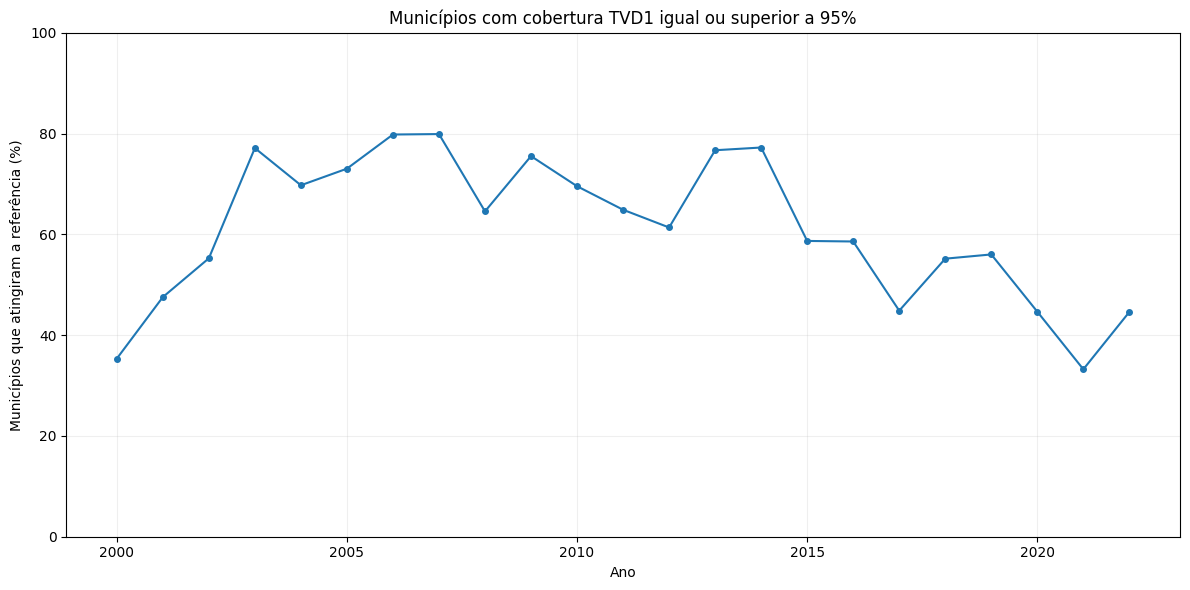

In [0]:
pdf_meta_municipio = df_meta_municipio.toPandas()

plt.figure(figsize=(12, 6))

plt.plot(
    pdf_meta_municipio["ano"],
    pdf_meta_municipio["percentual_meta"],
    marker="o",
    markersize=4
)

plt.title("Municípios com cobertura TVD1 igual ou superior a 95%")
plt.xlabel("Ano")
plt.ylabel("Municípios que atingiram a referência (%)")

plt.ylim(0, 100)
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

In [0]:
Nos primeiros anos analisados houve um aumento dos municípios que alcançaram esse patamar, com oscilações ao longo dos anos. Nos anos mais recentes, pode-se observar uma redução acompanhando a queda que observamos na análise regional. 

In [0]:
# Dados de TVD1 por região entre 2013 e 2022
pdf_heatmap = (
    df_regiao
    .filter(F.col("ano") >= 2013)
    .select("ano", "regiao", "cobertura_tvd1")
    .toPandas()
)

# Formato matriz: região x ano
matriz_heatmap = pdf_heatmap.pivot(
    index="regiao",
    columns="ano",
    values="cobertura_tvd1"
)

matriz_heatmap

ano,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
regiao,,,,,,,,,,
Centro-Oeste,112.38,122.52,93.73,99.47,83.35,91.00,91.28,79.91,80.25,86.56
Nordeste,111.99,116.89,95.31,97.21,87.07,94.60,94.42,79.34,70.44,80.36
Norte,98.93,116.05,85.60,80.76,76.18,84.69,88.27,69.22,68.53,73.24
Sudeste,105.53,107.61,99.92,98.07,88.65,94.61,94.06,83.41,75.56,78.21
Sul,107.25,111.04,96.12,93.02,87.26,89.97,92.67,86.47,84.47,90.80


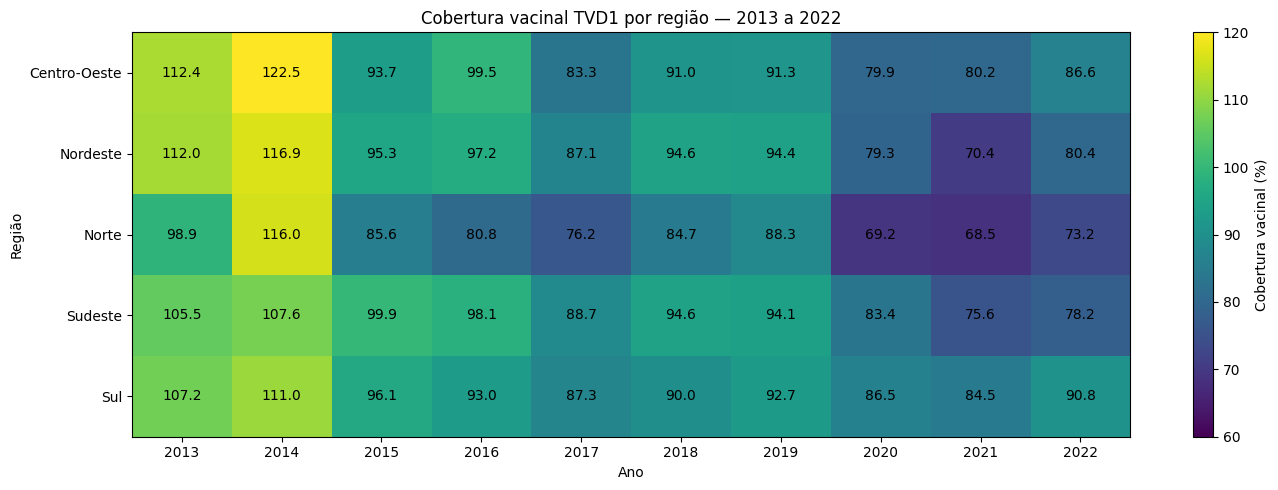

In [0]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

# Criação do heatmap
imagem = ax.imshow(
    matriz_heatmap.values,
    aspect="auto",
    vmin=60,
    vmax=120
)

# Eixos
ax.set_xticks(np.arange(len(matriz_heatmap.columns)))
ax.set_xticklabels(matriz_heatmap.columns)

ax.set_yticks(np.arange(len(matriz_heatmap.index)))
ax.set_yticklabels(matriz_heatmap.index)

# Valores dentro das células
for i in range(len(matriz_heatmap.index)):
    for j in range(len(matriz_heatmap.columns)):
        valor = matriz_heatmap.iloc[i, j]

        ax.text(
            j,
            i,
            f"{valor:.1f}",
            ha="center",
            va="center"
        )

# Barra lateral de escala
cbar = plt.colorbar(imagem, ax=ax)
cbar.set_label("Cobertura vacinal (%)")

plt.title("Cobertura vacinal TVD1 por região — 2013 a 2022")
plt.xlabel("Ano")
plt.ylabel("Região")

plt.tight_layout()
plt.show()

In [0]:
O mapa de calor permite enxergar uma mudança no padrão da cobertura regional ao longo do tempo. Em 2013 e 2014, todas as regiões atingiam a meta da cobertura vacinal recomendada, porém nos anos seguintes observa-se um decaimento da cobertura, com intensidades diferentes. Nos anos mais recentes é onde ocorre a redução com mais força, onde as regiões apresentaram cobertura abaixo de 95% e a região norte apresentou os menores valores. Esse mapa consegue exemplificar as diferenças territoriais da aplicação da vacina.

In [0]:
df_uf_2022 = (
    df_uf
    .filter(F.col("ano") == 2022)
    .select(
        "codigo_uf",
        "uf",
        "cobertura_tvd1",
        "cobertura_tvd2",
        "cobertura_scrvz"
    )
    .orderBy(F.desc("cobertura_tvd1"))
)

display(df_uf_2022)

codigo_uf,uf,cobertura_tvd1,cobertura_tvd2,cobertura_scrvz
42,Santa Catarina,94.94,72.35,9.21
50,Mato Grosso do Sul,91.83,49.56,14.8
53,Distrito Federal,90.23,61.5,2.29
41,Paraná,90.1,68.59,14.24
27,Alagoas,89.74,61.25,16.94
11,Rondônia,89.16,48.34,9.81
23,Ceará,89.01,66.26,6.95
43,Rio Grande do Sul,88.48,62.59,9.23
31,Minas Gerais,87.11,68.27,8.93
51,Mato Grosso,87.06,46.07,9.58


6. Cobertura da TVD1 por Unidade da Federação em 2022

Para complementar a análise regional e municipal, foi comparada a cobertura da TVD1 entre as 27 Unidades da Federação no último ano disponível da série.

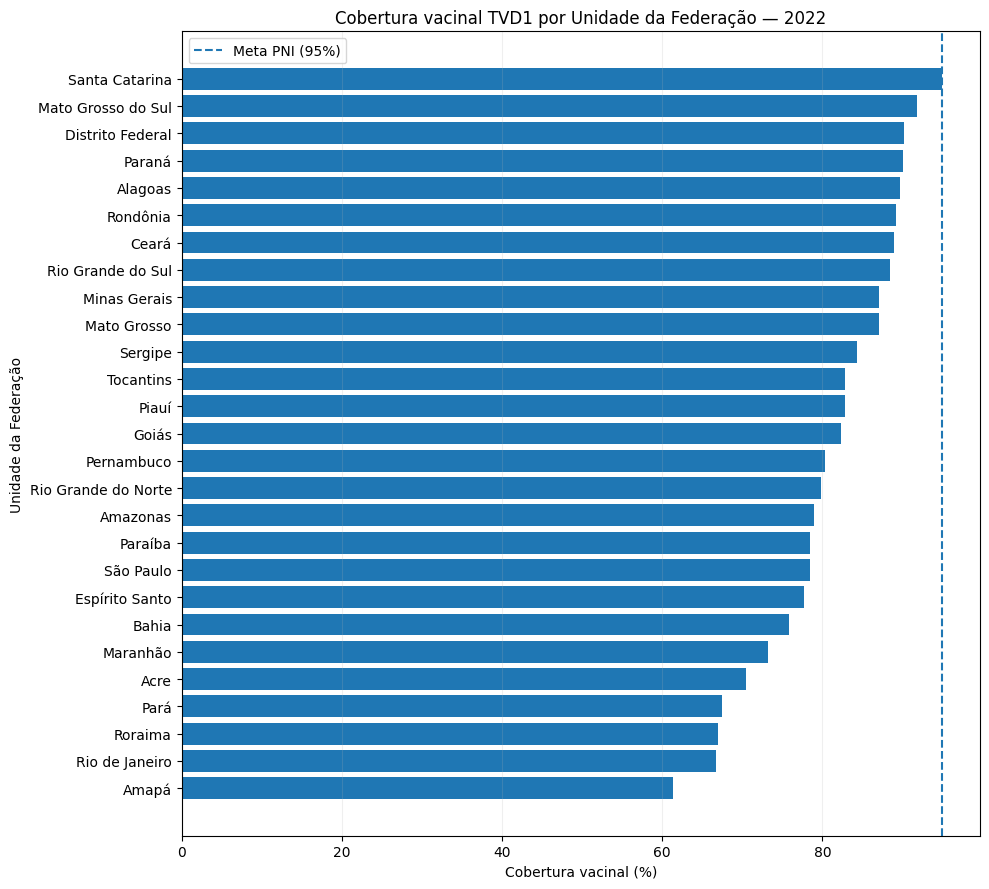

In [0]:
pdf_uf_2022 = (
    df_uf_2022
    .select("uf", "cobertura_tvd1")
    .orderBy("cobertura_tvd1")
    .toPandas()
)

plt.figure(figsize=(10, 9))

plt.barh(
    pdf_uf_2022["uf"],
    pdf_uf_2022["cobertura_tvd1"]
)

# Referência de 95%
plt.axvline(
    x=95,
    linestyle="--",
    linewidth=1.5,
    label="Meta PNI (95%)"
)

plt.title("Cobertura vacinal TVD1 por Unidade da Federação — 2022")
plt.xlabel("Cobertura vacinal (%)")
plt.ylabel("Unidade da Federação")

plt.legend()
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()

plt.show()

In [0]:
Em 2022, nenhum dos 27 Estados do Brasil alcançou a meta de vacinar 95% do público alvo, apesar de Santa Catarina chegar bem próximo, com 94,9%, seguido por Mato Grosso do Sul com 91,83% e Distrito Federal com 90,23%. O Amapá registra a menor cobertura vacinal com valor de 61,33%.

In [0]:
df_pib_cobertura_2022 = (
    df_municipio
    .filter(
        (F.col("ano") == 2022) &
        F.col("pib_mil_reais").isNotNull() &
        F.col("cobertura_tvd1").isNotNull() &
        (F.col("pib_mil_reais") > 0)
    )
    .select(
        "codigo_municipio",
        "municipio",
        "codigo_uf",
        "pib_mil_reais",
        "cobertura_tvd1"
    )
)

print("Municípios utilizados na análise:",
      df_pib_cobertura_2022.count())

display(df_pib_cobertura_2022.limit(10))

Municípios utilizados na análise: 5570


codigo_municipio,municipio,codigo_uf,pib_mil_reais,cobertura_tvd1
110010,GUAJARA-MIRIM,11,1057883.0,58.39
110015,OURO PRETO DO OESTE,11,1089382.0,77.17
110037,ALTO ALEGRE DOS PARECIS,11,570360.0,126.03
110120,MINISTRO ANDREAZZA,11,414490.0,124.32
120038,PLACIDO DE CASTRO,12,829047.0,67.02
120045,SENADOR GUIOMARD,12,1037716.0,65.09
120060,TARAUACA,12,800496.0,47.29
130130,CODAJAS,13,522891.0,84.39
130140,EIRUNEPE,13,578742.0,69.74
130340,PARINTINS,13,1511650.0,88.75


In [0]:
df_pib_grupo = (
    df_pib_cobertura_2022
    .withColumn(
        "situacao_cobertura",
        F.when(
            F.col("cobertura_tvd1") >= 95,
            "Atingiu 95%"
        ).otherwise("Abaixo de 95%")
    )
    .groupBy("situacao_cobertura")
    .agg(
        F.count("*").alias("quantidade_municipios"),
        F.round(
            F.avg("pib_mil_reais"),
            2
        ).alias("pib_medio_mil_reais"),
        F.round(
            F.expr("percentile_approx(pib_mil_reais, 0.5)"),
            2
        ).alias("pib_mediano_mil_reais")
    )
)

display(df_pib_grupo)

situacao_cobertura,quantidade_municipios,pib_medio_mil_reais,pib_mediano_mil_reais
Abaixo de 95%,3085,2776158.94,357094.0
Atingiu 95%,2485,609748.91,202283.0


In [0]:
#Soma do PIB por região
df_pib_regiao = (
    df_municipio
    .filter(
        (F.col("ano") >= 2002) &
        (F.col("ano") <= 2022) &
        F.col("pib_mil_reais").isNotNull()
    )
    .withColumn(
        "regiao",
        F.when(F.col("codigo_uf").substr(1, 1) == "1", "Norte")
         .when(F.col("codigo_uf").substr(1, 1) == "2", "Nordeste")
         .when(F.col("codigo_uf").substr(1, 1) == "3", "Sudeste")
         .when(F.col("codigo_uf").substr(1, 1) == "4", "Sul")
         .when(F.col("codigo_uf").substr(1, 1) == "5", "Centro-Oeste")
    )
    .groupBy("ano", "regiao")
    .agg(
        F.sum("pib_mil_reais").alias("pib_total_mil_reais")
    )
    .withColumn(
        "pib_bilhoes",
        F.round(
            F.col("pib_total_mil_reais") / 1_000_000,
            2
        )
    )
    .select(
        "ano",
        "regiao",
        "pib_bilhoes"
    )
    .orderBy("ano", "regiao")
)

display(df_pib_regiao)

ano,regiao,pib_bilhoes
2002,Centro-Oeste,128.16
2002,Nordeste,194.85
2002,Norte,69.9
2002,Sudeste,854.31
2002,Sul,241.56
2003,Centro-Oeste,152.56
2003,Nordeste,220.57
2003,Norte,81.55
2003,Sudeste,969.8
2003,Sul,293.46


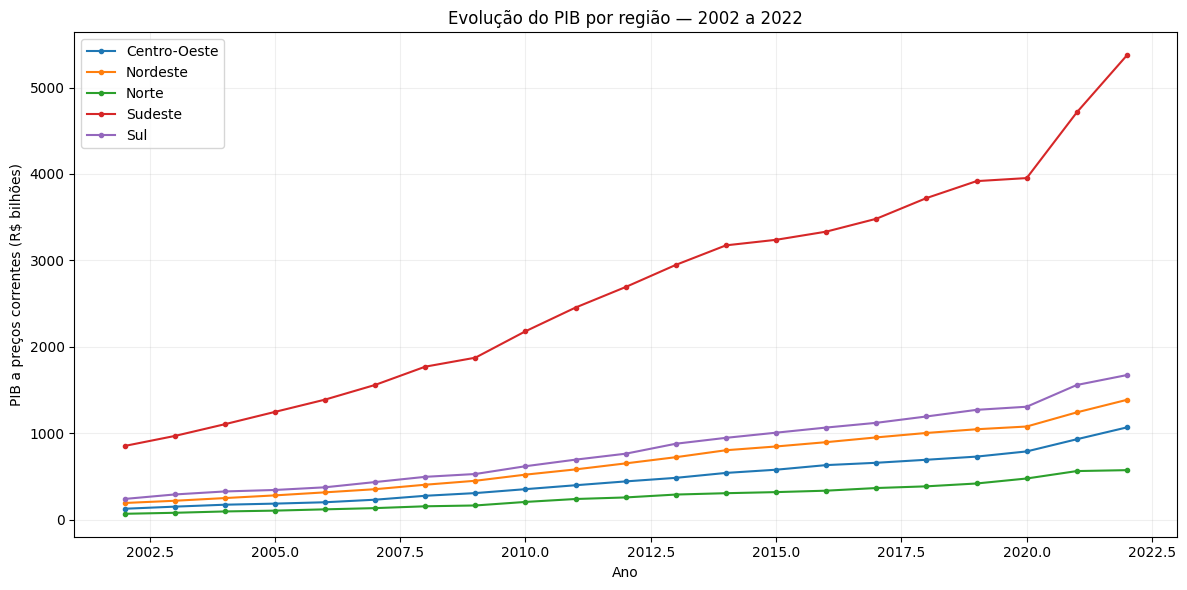

In [0]:
pdf_pib_regiao = df_pib_regiao.toPandas()

plt.figure(figsize=(12, 6))

for regiao in pdf_pib_regiao["regiao"].unique():
    dados = pdf_pib_regiao[
        pdf_pib_regiao["regiao"] == regiao
    ]

    plt.plot(
        dados["ano"],
        dados["pib_bilhoes"],
        marker="o",
        markersize=3,
        label=regiao
    )

plt.title("Evolução do PIB por região — 2002 a 2022")
plt.xlabel("Ano")
plt.ylabel("PIB a preços correntes (R$ bilhões)")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

Fiz algumas tentativas de correlacionar o PIB mas não consegui de forma consistente. Acredito que deva ter alguma forma de correlacionar esses dois temas, mas talvez seja necessário mais tempo e mais estudos.